In [209]:
# QUESTION 1(a)
import pandas as pd

index = pd.MultiIndex.from_arrays([['North','North','South','North','North','South'],['West','East','Central','West','East','Central']])

data = pd.Series([500,600,700,550,620,750], index)
data

North  West       500
       East       600
South  Central    700
North  West       550
       East       620
South  Central    750
dtype: int64

In [211]:
# QUESTION 1(b)
data.index.names = ["Region","Sub-region"]
data.name = "Sales"
data

Region  Sub-region
North   West          500
        East          600
South   Central       700
North   West          550
        East          620
South   Central       750
Name: Sales, dtype: int64

In [213]:
# QUESTION 1(c)
total_south = data['South'].sum()
total_south

1450

In [215]:
# QUESTION 1(d)
total_region = data.groupby('Region').sum()
total_region

Region
North    2270
South    1450
Name: Sales, dtype: int64

In [217]:
# QUESTION 1(e)
total_subregion = data.groupby('Sub-region').sum()
total_subregion

Sub-region
Central    1450
East       1220
West       1050
Name: Sales, dtype: int64

In [219]:
# QUESTION 1(f)
df = pd.DataFrame(data)
df

Sales
Region Sub-region       
North  West          500
       East          600
South  Central       700
North  West          550
       East          620
South  Central       750

In [223]:
# QUESTION 1(g)
sorted_data = df.sort_values(by = 'Sales', ascending = False)
sorted_data

Sales
Region Sub-region       
South  Central       750
       Central       700
North  East          620
       East          600
       West          550
       West          500

In [115]:
# QUESTION 2(a)
import pandas as pd

pop = pd.DataFrame(pd.read_csv('state-population.csv'))
areas = pd.DataFrame(pd.read_csv('state-areas.csv'))
abbrevs = pd.DataFrame(pd.read_csv('state-abbrevs.csv'))

pop.head()
areas.head()
abbrevs.head()

,state,abbreviation
0,Alabama,AL
1,Alaska,AK
2,Arizona,AZ
3,Arkansas,AR
4,California,CA


In [167]:
# QUESTION 2(b)
merged = pd.merge(pop,abbrevs, left_on = 'state/region',right_on = 'abbreviation')
merged

,state/region,ages,year,population,state,abbreviation
0,AL,under18,2012,1117489.0,Alabama,AL
1,AL,total,2012,4817528.0,Alabama,AL
2,AL,under18,2010,1130966.0,Alabama,AL
3,AL,total,2010,4785570.0,Alabama,AL
4,AL,under18,2011,1125763.0,Alabama,AL
...,...,...,...,...,...,...
2443,WY,under18,1993,137458.0,Wyoming,WY
2444,WY,total,1991,459260.0,Wyoming,WY
2445,WY,under18,1991,136720.0,Wyoming,WY
2446,WY,under18,1990,136078.0,Wyoming,WY


In [169]:
# QUESTION 2(c)
merged_T = merged.T
merged_T.duplicated()

merged = merged_T.drop_duplicates().T
merged

,state/region,ages,year,population,state
0,AL,under18,2012,1117489.0,Alabama
1,AL,total,2012,4817528.0,Alabama
2,AL,under18,2010,1130966.0,Alabama
3,AL,total,2010,4785570.0,Alabama
4,AL,under18,2011,1125763.0,Alabama
...,...,...,...,...,...
2443,WY,under18,1993,137458.0,Wyoming
2444,WY,total,1991,459260.0,Wyoming
2445,WY,under18,1991,136720.0,Wyoming
2446,WY,under18,1990,136078.0,Wyoming


In [171]:
# QUESTION 2(d)
merged.isnull().sum()

state/region    0
ages            0
year            0
population      0
state           0
dtype: int64

In [175]:
# QUESTION 2(e)
final = pd.merge(merged,areas, on = 'state')
final.head()

,state/region,ages,year,population,state,area (sq. mi)
0,AL,under18,2012,1117489.0,Alabama,52423
1,AL,total,2012,4817528.0,Alabama,52423
2,AL,under18,2010,1130966.0,Alabama,52423
3,AL,total,2010,4785570.0,Alabama,52423
4,AL,under18,2011,1125763.0,Alabama,52423


In [177]:
# QUESTION 2(f)
final.isnull().sum()

state/region     0
ages             0
year             0
population       0
state            0
area (sq. mi)    0
dtype: int64

In [195]:
# QUESTION 2(g)
Data2010 = final.query("year == 2010 & ages == 'total'")
Data2010

,state/region,ages,year,population,state,area (sq. mi)
3,AL,total,2010,4785570.0,Alabama,52423
91,AK,total,2010,713868.0,Alaska,656425
101,AZ,total,2010,6408790.0,Arizona,114006
189,AR,total,2010,2922280.0,Arkansas,53182
197,CA,total,2010,37333601.0,California,163707
283,CO,total,2010,5048196.0,Colorado,104100
293,CT,total,2010,3579210.0,Connecticut,5544
379,DE,total,2010,899711.0,Delaware,1954
389,DC,total,2010,605125.0,District of Columbia,68
475,FL,total,2010,18846054.0,Florida,65758


In [197]:
# QUESTION 2(g)(a)
Data2010 = Data2010.set_index('state')
Data2010.head()

,state/region,ages,year,population,area (sq. mi)
state,,,,,
Alabama,AL,total,2010,4785570.0,52423
Alaska,AK,total,2010,713868.0,656425
Arizona,AZ,total,2010,6408790.0,114006
Arkansas,AR,total,2010,2922280.0,53182
California,CA,total,2010,37333601.0,163707


In [199]:
# QUESTION 2(g)(b)
Data2010['density'] = Data2010['population']/Data2010['area (sq. mi)']
Data2010.head()

,state/region,ages,year,population,area (sq. mi),density
state,,,,,,
Alabama,AL,total,2010,4785570.0,52423,91.287603
Alaska,AK,total,2010,713868.0,656425,1.087509
Arizona,AZ,total,2010,6408790.0,114006,56.214497
Arkansas,AR,total,2010,2922280.0,53182,54.948667
California,CA,total,2010,37333601.0,163707,228.051342


In [205]:
# QUESTION 2(g)(c)
sorted_value = Data2010.sort_values(by = 'density', ascending = False)
sorted_value

,state/region,ages,year,population,area (sq. mi),density
state,,,,,,
District of Columbia,DC,total,2010,605125.0,68,8898.897059
New Jersey,NJ,total,2010,8802707.0,8722,1009.253268
Rhode Island,RI,total,2010,1052669.0,1545,681.339159
Connecticut,CT,total,2010,3579210.0,5544,645.600649
Massachusetts,MA,total,2010,6563263.0,10555,621.815538
Maryland,MD,total,2010,5787193.0,12407,466.445797
Delaware,DE,total,2010,899711.0,1954,460.445752
New York,NY,total,2010,19398228.0,54475,356.094135
Florida,FL,total,2010,18846054.0,65758,286.597129


In [227]:
# QUESTION 2(g)(d)
sorted_value.tail()

,state/region,ages,year,population,area (sq. mi),density
state,,,,,,
South Dakota,SD,total,2010,816211.0,77121,10.583512
North Dakota,ND,total,2010,674344.0,70704,9.537565
Montana,MT,total,2010,990527.0,147046,6.736171
Wyoming,WY,total,2010,564222.0,97818,5.768079
Alaska,AK,total,2010,713868.0,656425,1.087509


In [239]:
# QUESTION 3(a)
import pandas as pd

performance = pd.read_csv('employee_performance_data.csv')
performance.set_index('Employee_ID')
performance

,Employee_ID,Name,Department,Monthly_Salary,Years_at_Company,Performance_Score,Last_Promotion_Year,Work_Location
0,101,Employee 1,Marketing,6021,6,4.7,2024,Rural
1,102,Employee 2,HR,4073,3,3.1,2021,Urban
2,103,Employee 3,Sales,7613,12,3.7,2024,Rural
3,104,Employee 4,IT,4276,1,4.3,2016,Urban
4,105,Employee 5,IT,7720,7,4.0,2018,Rural
5,106,Employee 6,HR,5202,13,4.6,2023,Rural
6,107,Employee 7,HR,4625,10,5.0,2023,Rural
7,108,Employee 8,Finance,3034,10,3.8,2022,Rural
8,109,Employee 9,Marketing,4408,1,2.9,2021,Urban
9,110,Employee 10,Marketing,3817,11,3.4,2022,Urban


In [243]:
# QUESTION 3(b)
records = performance.query("Department == 'Sales' & Performance_Score > 4")
records

,Employee_ID,Name,Department,Monthly_Salary,Years_at_Company,Performance_Score,Last_Promotion_Year,Work_Location
11,112,Employee 12,Sales,6566,5,5.0,2021,Rural
17,118,Employee 18,Sales,5184,6,5.0,2019,Rural
19,120,Employee 20,Sales,6462,1,4.1,2016,Rural
24,125,Employee 25,Sales,3282,15,4.2,2023,Urban
27,128,Employee 28,Sales,5820,14,4.9,2021,Rural


In [249]:
# QUESTION 3(c)
details = pd.read_csv("employee_details.csv")
merged = pd.merge(performance, details, on = 'Employee_ID')
merged

,Employee_ID,Name,Department,Monthly_Salary,Years_at_Company,Performance_Score,Last_Promotion_Year,Work_Location,Email,Phone_Number
0,101,Employee 1,Marketing,6021,6,4.7,2024,Rural,alice.johnson@example.com,1234567890
1,102,Employee 2,HR,4073,3,3.1,2021,Urban,bob.smith@example.com,2345678901
2,103,Employee 3,Sales,7613,12,3.7,2024,Rural,cathy.lee@example.com,3456789012
3,104,Employee 4,IT,4276,1,4.3,2016,Urban,david.brown@example.com,4567890123
4,105,Employee 5,IT,7720,7,4.0,2018,Rural,emma.wilson@example.com,5678901234
5,106,Employee 6,HR,5202,13,4.6,2023,Rural,frank.knight@example.com,6789012345
6,107,Employee 7,HR,4625,10,5.0,2023,Rural,grace.white@example.com,7890123456


In [251]:
# QUESTION 3(d)
high_salary_employees = merged.query("Monthly_Salary > 4500")
high_salary_employees

,Employee_ID,Name,Department,Monthly_Salary,Years_at_Company,Performance_Score,Last_Promotion_Year,Work_Location,Email,Phone_Number
0,101,Employee 1,Marketing,6021,6,4.7,2024,Rural,alice.johnson@example.com,1234567890
2,103,Employee 3,Sales,7613,12,3.7,2024,Rural,cathy.lee@example.com,3456789012
4,105,Employee 5,IT,7720,7,4.0,2018,Rural,emma.wilson@example.com,5678901234
5,106,Employee 6,HR,5202,13,4.6,2023,Rural,frank.knight@example.com,6789012345
6,107,Employee 7,HR,4625,10,5.0,2023,Rural,grace.white@example.com,7890123456


In [257]:
# QUESTION 3(e)
email_list = merged['Email'].tolist()
email_list

['alice.johnson@example.com',
 'bob.smith@example.com',
 'cathy.lee@example.com',
 'david.brown@example.com',
 'emma.wilson@example.com',
 'frank.knight@example.com',
 'grace.white@example.com']

In [269]:
# QUESTION 3(f)
descending = merged.sort_values(by = ['Department','Performance_Score'], ascending = [True,False])
descending

,Employee_ID,Name,Department,Monthly_Salary,Years_at_Company,Performance_Score,Last_Promotion_Year,Work_Location,Email,Phone_Number,email_list
6,107,Employee 7,HR,4625,10,5.0,2023,Rural,grace.white@example.com,7890123456,grace.white@example.com
5,106,Employee 6,HR,5202,13,4.6,2023,Rural,frank.knight@example.com,6789012345,frank.knight@example.com
1,102,Employee 2,HR,4073,3,3.1,2021,Urban,bob.smith@example.com,2345678901,bob.smith@example.com
3,104,Employee 4,IT,4276,1,4.3,2016,Urban,david.brown@example.com,4567890123,david.brown@example.com
4,105,Employee 5,IT,7720,7,4.0,2018,Rural,emma.wilson@example.com,5678901234,emma.wilson@example.com
0,101,Employee 1,Marketing,6021,6,4.7,2024,Rural,alice.johnson@example.com,1234567890,alice.johnson@example.com
2,103,Employee 3,Sales,7613,12,3.7,2024,Rural,cathy.lee@example.com,3456789012,cathy.lee@example.com


In [271]:
# QUESTION 3(g)
merged_new = merged.reindex(columns = ['Name','Department','Monthly_Salary','Performance_Score','Email','Phone_Number'])
merged_new

,Name,Department,Monthly_Salary,Performance_Score,Email,Phone_Number
0,Employee 1,Marketing,6021,4.7,alice.johnson@example.com,1234567890
1,Employee 2,HR,4073,3.1,bob.smith@example.com,2345678901
2,Employee 3,Sales,7613,3.7,cathy.lee@example.com,3456789012
3,Employee 4,IT,4276,4.3,david.brown@example.com,4567890123
4,Employee 5,IT,7720,4.0,emma.wilson@example.com,5678901234
5,Employee 6,HR,5202,4.6,frank.knight@example.com,6789012345
6,Employee 7,HR,4625,5.0,grace.white@example.com,7890123456


In [279]:
# QUESTION 3(h)
merged['difference'] = 2024 - merged['Last_Promotion_Year']
merged

,Employee_ID,Name,Department,Monthly_Salary,Years_at_Company,Performance_Score,Last_Promotion_Year,Work_Location,Email,Phone_Number,email_list,difference
0,101,Employee 1,Marketing,6021,6,4.7,2024,Rural,alice.johnson@example.com,1234567890,alice.johnson@example.com,0
1,102,Employee 2,HR,4073,3,3.1,2021,Urban,bob.smith@example.com,2345678901,bob.smith@example.com,3
2,103,Employee 3,Sales,7613,12,3.7,2024,Rural,cathy.lee@example.com,3456789012,cathy.lee@example.com,0
3,104,Employee 4,IT,4276,1,4.3,2016,Urban,david.brown@example.com,4567890123,david.brown@example.com,8
4,105,Employee 5,IT,7720,7,4.0,2018,Rural,emma.wilson@example.com,5678901234,emma.wilson@example.com,6
5,106,Employee 6,HR,5202,13,4.6,2023,Rural,frank.knight@example.com,6789012345,frank.knight@example.com,1
6,107,Employee 7,HR,4625,10,5.0,2023,Rural,grace.white@example.com,7890123456,grace.white@example.com,1


In [285]:
# QUESTION 3(i)
import numpy as np

# Define conditions
condition1 = merged['difference'] <= 2
condition2 = (merged['difference'] > 5) & (merged['Performance_Score'] >= 4)

# Use np.select to assign values based on conditions
merged['Promotion_Status'] = np.select(
    [condition1, condition2],
    ['Recently Promoted', 'Due for Promotion'],
    default='No Promotion Needed'
)

# Display result
merged


,Employee_ID,Name,Department,Monthly_Salary,Years_at_Company,Performance_Score,Last_Promotion_Year,Work_Location,Email,Phone_Number,email_list,difference,Promotion_Status
0,101,Employee 1,Marketing,6021,6,4.7,2024,Rural,alice.johnson@example.com,1234567890,alice.johnson@example.com,0,Recently Promoted
1,102,Employee 2,HR,4073,3,3.1,2021,Urban,bob.smith@example.com,2345678901,bob.smith@example.com,3,No Promotion Needed
2,103,Employee 3,Sales,7613,12,3.7,2024,Rural,cathy.lee@example.com,3456789012,cathy.lee@example.com,0,Recently Promoted
3,104,Employee 4,IT,4276,1,4.3,2016,Urban,david.brown@example.com,4567890123,david.brown@example.com,8,Due for Promotion
4,105,Employee 5,IT,7720,7,4.0,2018,Rural,emma.wilson@example.com,5678901234,emma.wilson@example.com,6,Due for Promotion
5,106,Employee 6,HR,5202,13,4.6,2023,Rural,frank.knight@example.com,6789012345,frank.knight@example.com,1,Recently Promoted
6,107,Employee 7,HR,4625,10,5.0,2023,Rural,grace.white@example.com,7890123456,grace.white@example.com,1,Recently Promoted


In [305]:
# QUESTION 4(a)
import matplotlib.pyplot as plt
import pandas as pd

data = pd.read_csv('products_sales.csv')
data

,Product_ID,Category,Region,Units_Sold,Revenue,Profit,Month
0,1,Toys,East,33,47892,12787,June
1,2,Clothing,East,56,38106,6596,December
2,3,Furniture,East,457,35707,6373,October
3,4,Electronics,East,45,16516,1346,September
4,5,Toys,West,126,2045,5014,November
...,...,...,...,...,...,...,...
95,96,Furniture,West,12,43395,2523,March
96,97,Books,West,436,39889,7999,April
97,98,Toys,South,299,41829,12236,September
98,99,Toys,North,180,21778,17123,September


In [317]:
category_revenue = data.groupby('Category')['Revenue'].sum()
category_revenue

Category
Books          331317
Clothing       413142
Electronics    452286
Furniture      472348
Toys           651777
Name: Revenue, dtype: int64

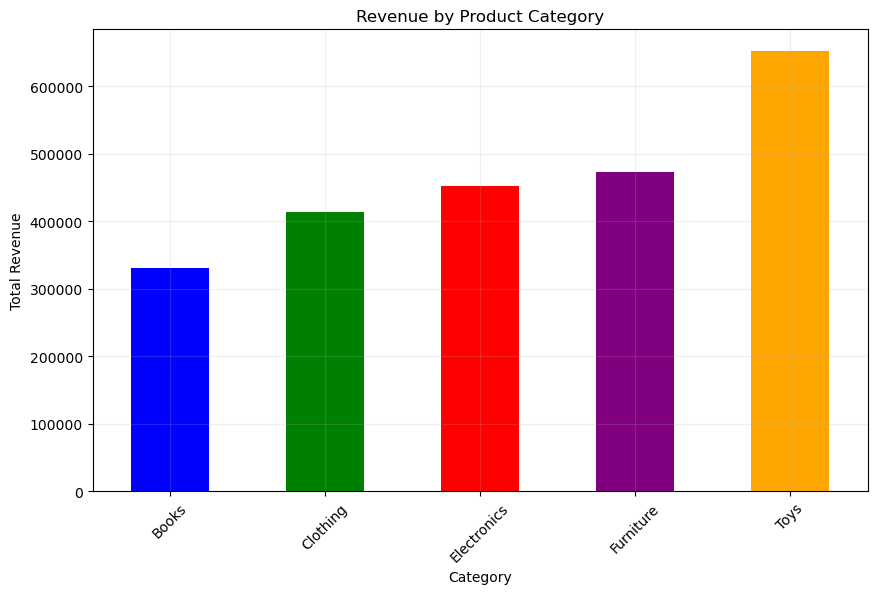

In [339]:
fig, axes = plt.subplots(figsize = (10,6))
category_revenue.plot.bar(ax = axes, color = ['blue','green','red','purple','orange'])

axes.set_title("Revenue by Product Category")
axes.set_xlabel("Category")
axes.set_ylabel("Total Revenue")

plt.xticks(rotation = 45)
plt.grid(True, alpha = 0.2)

### QUESTION 4(b)
### Answer: Toys

### QUESTION 4(c)
### Answer: Yes !

Text(0, 0.5, 'Total Revenue')

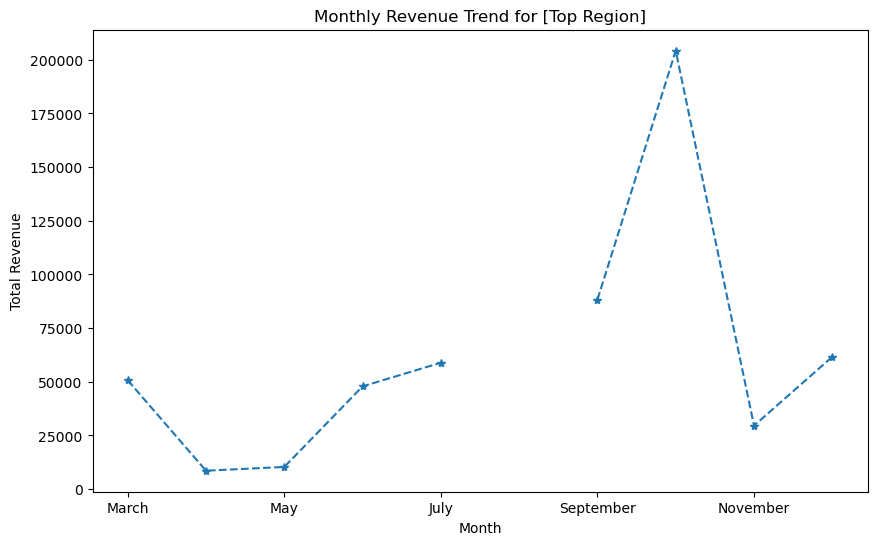

In [373]:
# QUESTION 4(d)

import pandas as pd
import matplotlib.pyplot as plt

revenue_region = data.groupby('Region')['Revenue'].sum()
index = revenue_region.idxmax()

top_region = data[data['Region'] == index]

revenue_month = top_region.groupby('Month')['Revenue'].sum()

month = ['Jan','Feb','March','April','May','June','July','August','September','October','November','December']
revenue_month = revenue_month.reindex(month)

fig, axes = plt.subplots(figsize = (10,6))
revenue_month.plot(ax = axes, marker = '*', ls = '--')

axes.set_title("Monthly Revenue Trend for [Top Region]")
axes.set_xlabel("Month")
axes.set_ylabel("Total Revenue")